Quantum Teleporation with Qiskit:
----------------------------------

In [1]:
import math
from pandas import DataFrame as df
import os
import numpy as np

import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.visualization import plot_bloch_vector, plot_histogram, plot_bloch_multivector, plot_state_city, plot_state_qsphere
from qiskit_aer import AerSimulator
from qiskit_aer import Aer

from qiskit.quantum_info import Statevector, Operator

Importing nessesary new libraries:

In [2]:
from qiskit.visualization import array_to_latex
from qiskit.circuit.library import Initialize
from qiskit.quantum_info import random_statevector

In [89]:
psi = random_statevector(2)
print('psi state:', psi)
array_to_latex(psi)

psi state: Statevector([-0.7988385+0.02458481j, -0.2691063+0.53743319j],
            dims=(2,))


<IPython.core.display.Latex object>

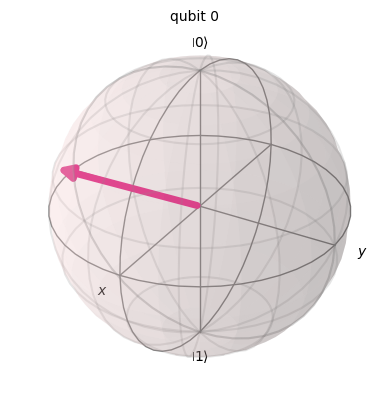

In [90]:
plot_bloch_multivector(psi)

In [91]:
init_state = Initialize(psi)
init_state.label = "initial_state"

In [92]:
def create_bell_pair(qc,a,b):
    qc.h(a)
    qc.cx(a,b)  

In [93]:
def alice_gates(qc,psi,a):
    qc.cx(psi,a)
    qc.h(psi)  

In [94]:
def measure_and_send(qc,a,b):
    qc.barrier()
    qc.measure(a,0)
    qc.measure(b,1)

In [95]:
def bob_gates(qc,qubit,crz,crx):
    qc.x(qubit).c_if(crx,1)
    qc.z(qubit).c_if(crz,1)

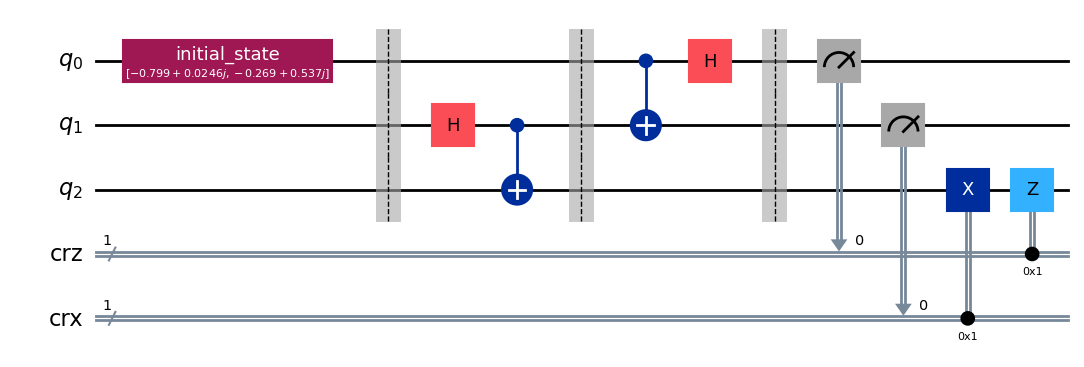

In [107]:
## SETUP
qr = QuantumRegister(3, name="q")   # Protocol uses 3 qubits
crz = ClassicalRegister(1, name="crz") # and 2 classical registers
crx = ClassicalRegister(1, name="crx")
qc = QuantumCircuit(qr, crz, crx)

## STEP 0
# First, let's initialize Alice's q0
qc.append(init_state, [0])
qc.barrier()

## STEP 1
# Now begins the teleportation protocol
create_bell_pair(qc, 1, 2)
qc.barrier()

## STEP 2
# Send q1 to Alice and q2 to Bob
alice_gates(qc, 0, 1)

## STEP 3
# Alice then sends her classical bits to Bob
measure_and_send(qc, 0, 1)

## STEP 4
# Bob decodes qubits
bob_gates(qc, 2, crz, crx)

# Display the circuit
qc.draw('mpl')


Bob's reduced density matrix:
 [[0.639+0.j    0.228+0.423j]
 [0.228-0.423j 0.361+0.j   ]]


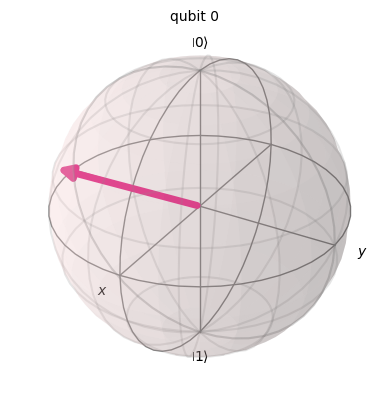

In [110]:
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.visualization import plot_bloch_multivector

sim = AerSimulator(method="density_matrix")

qc_sim = qc.copy()
qc_sim.save_density_matrix()

tqc = transpile(qc_sim, sim)
res = sim.run(tqc, shots=1).result()
rho = res.data(0)["density_matrix"]

# keep Bob's qubit (q2), trace out q0 and q1
rho_bob = partial_trace(DensityMatrix(rho), [0, 1])

print("\nBob's reduced density matrix:\n", np.round(rho_bob.data, 3))

# Plot Bob's qubit on Bloch sphere (works best if it's close to pure)
plot_bloch_multivector(rho_bob)


Total Counts are: {'11': 261, '00': 249, '10': 260, '01': 230}


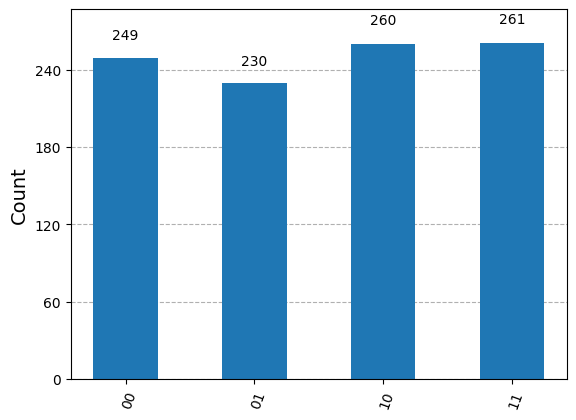

In [99]:
backend = Aer.get_backend('qasm_simulator') 

qct = transpile(qc, backend)
result = backend.run(qct, shots=1000).result()

counts = result.get_counts()
print("\nTotal Counts are:", counts)
plot_histogram(counts)

In [106]:
backend = Aer.get_backend("statevector_simulator")
result = execute(qc,backend).result().get_statevecopr
result = backend.run(tqc, shots=1000).result()
print(result.get_counts())

QiskitError: 'Cannot apply instruction with classical bits: measure'